## Import Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

## PROBLEM DEFINITION

Problem:
Develop a machine-learning system capable of identifying potentially fraudulent
mobile-money transactions in Nigeria.

Machine Learning Task:
Binary Classification

Goal:
Catch fraud hides in transactions.

## Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/NIBSS/nibss_fraud_dataset.csv',
                  index_col='transaction_id',
                  low_memory=False)

In [ ]:
pd.options.display.max_columns = 40

## Basic Data Inspection

In [ ]:
df.shape

(1000000, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, TXN_F08A86FFD87C to TXN_FB171C6B1B12
Data columns (total 37 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   customer_id           1000000 non-null  object 
 1   timestamp             1000000 non-null  object 
 2   amount                1000000 non-null  float64
 3   channel               1000000 non-null  object 
 4   merchant_category     1000000 non-null  object 
 5   bank                  1000000 non-null  object 
 6   location              1000000 non-null  object 
 7   age_group             1000000 non-null  object 
 8   hour                  1000000 non-null  int64  
 9   day_of_week           1000000 non-null  int64  
 10  month                 1000000 non-null  int64  
 11  is_weekend            1000000 non-null  bool   
 12  is_peak_hour          1000000 non-null  bool   
 13  tx_count_24h          1000000 non-null  float64
 14  amount_sum_24h 

In [ ]:
df.describe()

,amount,hour,day_of_week,month,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,amount_std_total,channel_diversity,location_diversity,amount_vs_mean_ratio,online_channel_ratio,is_fraud,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.0,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.569514e+05,12.228639,3.013070,6.609283,1.282159,1.991769e+05,1.557863e+05,1.112951e+05,100.985146,156224.102273,2.901578e+05,5.864267,1.0,0.999993,0.700237,0.00300,-0.085920,-0.466445,-0.001601,-0.003539,3.397843e-02,1.272586e-02,11.110517,0.000079,1.905117,0.395645,0.151286
std,3.263590e+05,4.798625,1.997767,3.464179,0.533265,3.742924e+05,2.184174e+05,2.091671e+05,9.900881,32450.494993,1.435335e+05,0.343522,0.0,1.858192,0.045526,0.05469,0.653980,0.589371,0.707580,0.706623,7.197222e-01,6.933142e-01,1.302152,0.008888,3.915378,0.238704,0.087124
min,1.685500e+02,0.000000,0.000000,1.000000,1.000000,1.685500e+02,2.128300e+02,0.000000e+00,61.000000,79531.073708,7.629456e+04,4.000000,1.0,0.001013,0.524390,0.00000,-1.000000,-1.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,5.133148,0.000000,0.001077,0.121274,0.036431
25%,2.800042e+04,9.000000,1.000000,3.000000,1.000000,3.617210e+04,5.327417e+04,1.421574e+04,94.000000,133244.011525,1.980980e+05,6.000000,1.0,0.181893,0.670000,0.00000,-0.707107,-0.866025,-0.781831,-0.900969,-5.000000e-01,-5.000000e-01,10.240010,0.000000,0.246675,0.202718,0.078078
50%,6.667998e+04,12.000000,3.000000,7.000000,1.000000,8.971861e+04,9.779375e+04,5.121962e+04,101.000000,151366.221635,2.528541e+05,6.000000,1.0,0.437315,0.701613,0.00000,0.000000,-0.707107,0.000000,-0.222521,-2.449294e-16,6.123234e-17,11.107675,0.000000,0.681163,0.369588,0.135629
75%,1.595289e+05,15.000000,5.000000,10.000000,1.000000,2.150990e+05,1.795145e+05,1.246082e+05,107.000000,174289.988391,3.373644e+05,6.000000,1.0,1.049607,0.730769,0.00000,0.500000,-0.258819,0.781831,0.623490,8.660254e-01,5.000000e-01,11.979987,0.000000,1.915726,0.542436,0.196458
max,1.792681e+07,23.000000,6.000000,12.000000,6.000000,1.326406e+07,1.000000e+07,4.998794e+06,140.000000,380508.803514,1.149815e+06,6.000000,1.0,54.904026,0.892857,1.00000,1.000000,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00,16.701808,1.000000,191.519506,0.877424,0.734583


## Data Cleaning

### Checking for missing values

In [ ]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False)

,0
fraud_technique,997000
timestamp,0
amount,0
channel,0
customer_id,0
merchant_category,0
bank,0
age_group,0
location,0
day_of_week,0


In [ ]:
## Handling the missing values
df["fraud_technique"] = df["fraud_technique"].fillna("NOT FRAUD")

### Checking for duplicate records

In [ ]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated(subset=['customer_id', 'timestamp', 'amount', 'channel',
       'merchant_category', 'bank', 'location', 'age_group', 'hour',
       'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'tx_count_24h',
       'amount_sum_24h', 'amount_mean_7d', 'amount_std_7d', 'tx_count_total',
       'amount_mean_total', 'amount_std_total', 'channel_diversity',
       'location_diversity', 'amount_vs_mean_ratio', 'online_channel_ratio',
       'is_fraud', 'fraud_technique', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'amount_log', 'amount_rounded',
       'velocity_score', 'merchant_risk_score', 'composite_risk']).any()

np.False_

In [ ]:
# Drop duplicates if exist
df = df.drop_duplicates()

### Fixing Datatypes

In [ ]:
# converting timestamp from object to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

In [ ]:
# converting some categorical columns from object to category
categorical = ["channel", "merchant_category", "bank", "location", "age_group", "fraud_technique"]
df[categorical] = df[categorical].astype("category")

In [ ]:
# converting these columns from float to integer since they are counts
count_cols = ["tx_count_24h", "tx_count_total"]
df[count_cols] = df[count_cols].astype("int32")

In [ ]:
# converting from boolean to integer for memory efficiency
df[["is_weekend", "is_peak_hour"]] = df[["is_weekend", "is_peak_hour"]].astype("int8")

In [ ]:
# Checking datatypes after transformation
df.dtypes

,0
customer_id,object
timestamp,datetime64[ns]
amount,float64
channel,category
merchant_category,category
bank,category
location,category
age_group,category
hour,int64
day_of_week,int64


### Dropping irrelevant columns

In [ ]:

df = df.drop(columns=['customer_id',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
    'composite_risk', 'location_diversity'], axis=1)

In [ ]:
df.shape

(1000000, 28)

In [ ]:
df.head()

,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,day_of_week,month,is_weekend,is_peak_hour,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,amount_std_total,channel_diversity,amount_vs_mean_ratio,online_channel_ratio,is_fraud,fraud_technique,amount_log,amount_rounded,velocity_score,merchant_risk_score
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TXN_F08A86FFD87C,2023-01-14 04:31:09,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,5,1,1,0,1,32266.83,32266.830000,0.000000,107,170389.868692,365915.900271,5,0.189369,0.775701,0,NOT FRAUD,10.381826,0,0.189369,0.215000
TXN_C2D08134EC83,2023-01-17 11:20:13,72530.49,Web,Entertainment,UBA,Other,30-39,11,1,1,0,1,1,72530.49,52398.660000,20131.830000,107,170389.868692,365915.900271,5,0.425671,0.775701,0,NOT FRAUD,11.191776,0,0.425671,0.877424
TXN_B9499111901D,2023-01-22 02:17:46,168152.87,Mobile,Transport,Wema,Other,30-39,2,6,1,1,0,1,168152.87,120341.680000,47811.190000,107,170389.868692,365915.900271,5,0.986866,0.775701,0,NOT FRAUD,12.032635,0,0.986866,0.440230
TXN_48DB1D526A3B,2023-01-24 08:18:23,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,1,1,0,0,1,16439.93,85707.763333,62633.507753,107,170389.868692,365915.900271,5,0.096484,0.775701,0,NOT FRAUD,9.707529,0,0.096484,0.877424
TXN_56DB1E28B758,2023-02-01 15:39:53,9922.68,POS,Education,FirstBank,Other,30-39,15,2,2,0,1,1,9922.68,9922.680000,0.000000,107,170389.868692,365915.900271,5,0.058235,0.775701,0,NOT FRAUD,9.202679,0,0.058235,0.231291


## Exploratory Data Analysis (EDA)

### Class Imbalance Check

In [ ]:
# Class Counts
fraud_counts = df["is_fraud"].value_counts()
fraud_counts

,count
is_fraud,
0,997000
1,3000


In [ ]:
# Fraud Ratio
df["is_fraud"].value_counts() / df.shape[0] * 100

,count
is_fraud,
0,99.7
1,0.3


The fraud ratio is just 0.3% of the dataset which indicate there is class imbalance

Text(0, 0.5, 'Number of transactions')

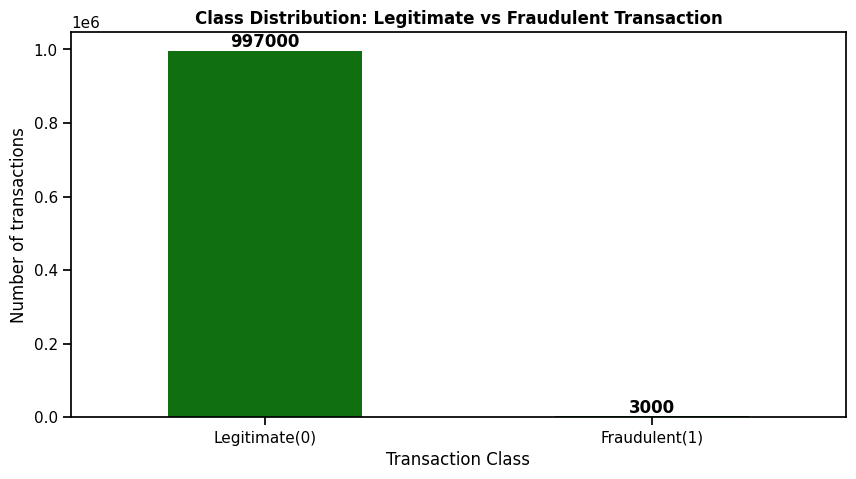

In [ ]:
## 1. Class Distribution
plt.figure(figsize=(10, 5))
ax = sns.barplot(x = fraud_counts.index, y = fraud_counts.values, color="green", width = 0.5)
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 10000, str(v), ha = "center", fontweight="bold")

ax.set_xticklabels(["Legitimate(0)", "Fraudulent(1)"])
plt.title("Class Distribution: Legitimate vs Fraudulent Transaction", fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of transactions")

The plot above shows the total number of legitimate transactions compare to the fraudulent transactions

## Fraud Rate by Amount Bucket

Text(0, 0.5, 'Fraud Rate (%)')

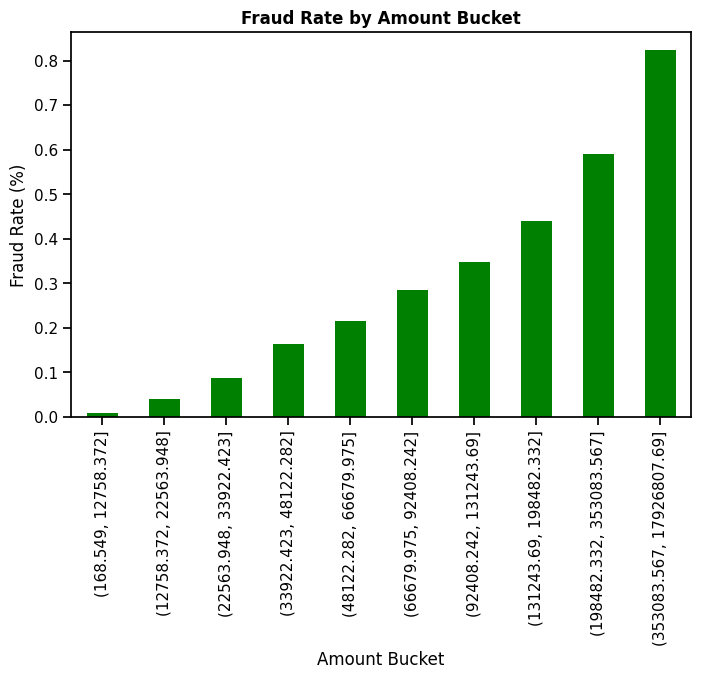

In [ ]:
# 1. Fraud Rate by Amount Bucket
plt.figure(figsize=(8, 5))
df["amount_bin"] = pd.qcut(df["amount"], q=10, duplicates='drop')
fraud_rate = df.groupby("amount_bin", observed=True)["is_fraud"].mean()
fraud_rate = fraud_rate * 100
fraud_rate.plot(kind="bar", color="green")
plt.title("Fraud Rate by Amount Bucket", fontweight="bold")
plt.xlabel("Amount Bucket")
plt.ylabel("Fraud Rate (%)")

This plot demonstrates transaction amount not just a magnitude feature but a great risk indicator with fraud likelihood increasing significantly in higher values within amount buckets

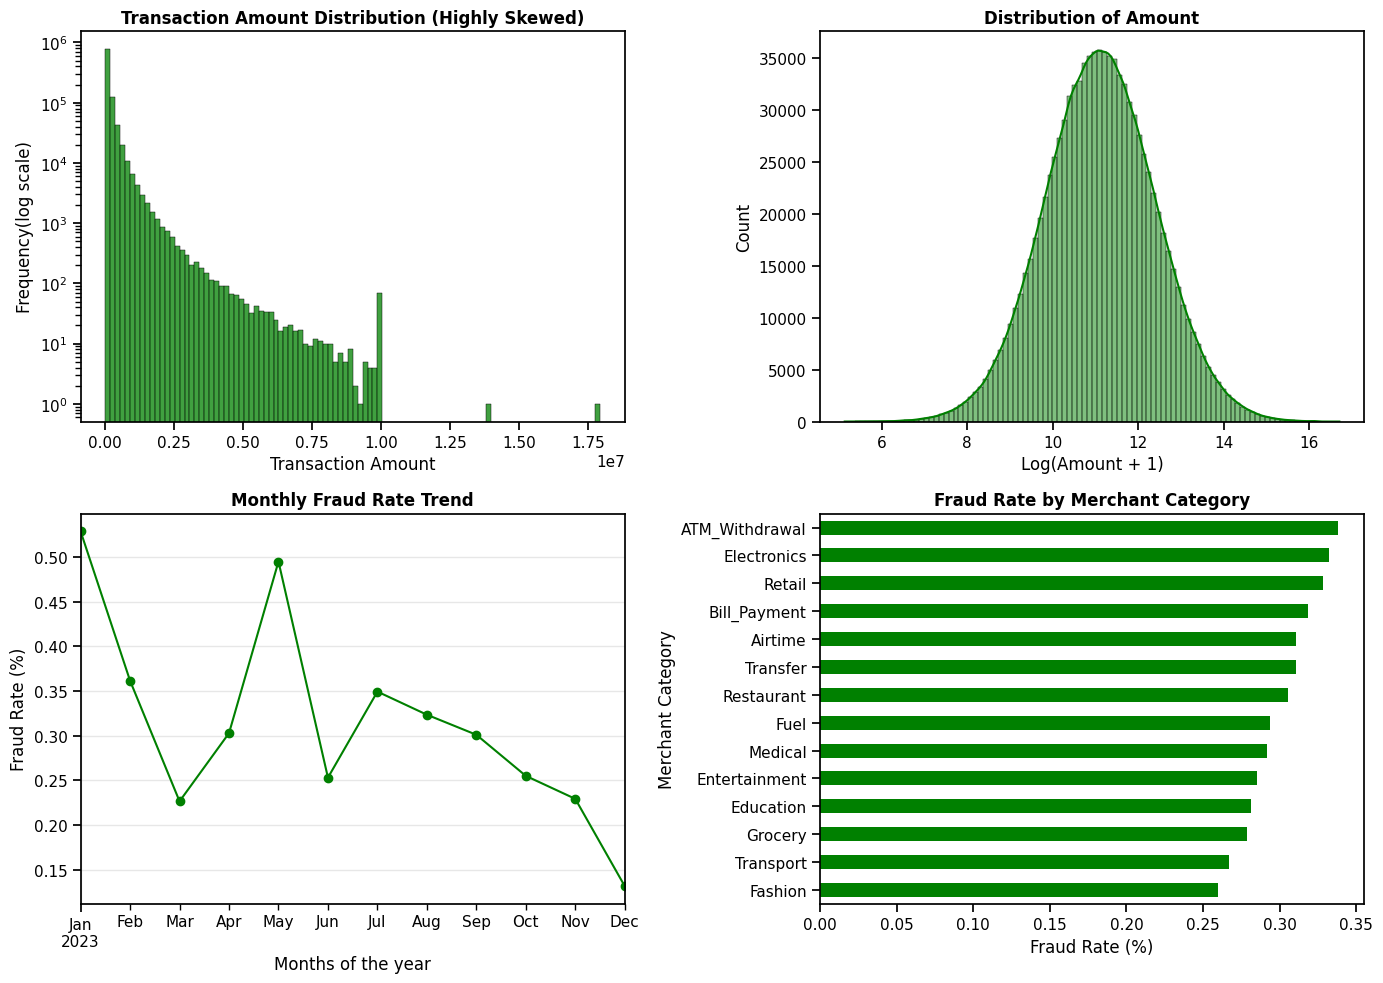

In [ ]:
plt.figure(figsize=(14, 10))

# 1. Transaction Amount Distribution
plt.subplot(2,2,1)
sns.histplot(df["amount"], bins=100, color="green")
plt.yscale("log")
plt.title("Transaction Amount Distribution (Highly Skewed)", fontweight="bold")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency(log scale)")

# 2. Amount Distribution (Log Transformation)
plt.subplot(2,2,2)
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Distribution of Amount", fontweight="bold")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Count")


# 3. Monthly Fraud Rate Trend
plt.subplot(2,2,3)
(df.set_index('timestamp').resample('ME')['is_fraud'].mean() * 100).plot(marker="o", color='green')
plt.title("Monthly Fraud Rate Trend", fontweight="bold")
plt.xlabel("Months of the year")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis='both', alpha=0.3)

# 4. Fraud Rate by Merchant Category
plt.subplot(2,2,4)
merch_fraud = (df.groupby("merchant_category", observed=True)["is_fraud"].mean() * 100).sort_values()
merch_fraud.plot(kind = "barh", color='green')
plt.title("Fraud Rate by Merchant Category", fontweight="bold")
plt.ylabel("Merchant Category")
plt.xlabel("Fraud Rate (%)")


plt.tight_layout()
plt.show()

The plots above show that:
1. The transaction amount is heavily right-skewed i.e. most of the transacations are bunched on one side of the data which is difficulty to read and use for training machine learning models.
2. The log transformation is used to reduce the skewness where most of the transactions are concentrated in the middle so that it will be readable and easily use to train machine learning models.
3. January and May top the list of the trend while the trend tends to be low from October to December. This may be a natural random fluctuation rather than a repeatable seasonal effect
4. ATM_withdrawal and Electronics show higher rates while Transport and Fashion show lower rates. The overall range is narrow demonstrating this is a weaker standalone predictor

### Fraud by Channel

In [ ]:
# Calculate fraud rate per Channel
fraud_channel = df.groupby('channel', observed=True)['is_fraud'].agg(['sum', 'count'])
fraud_channel.columns = ['fraud_count', 'total_transactions']
fraud_channel['fraud_rate'] = (fraud_channel['fraud_count'] / fraud_channel['total_transactions']) * 100

# Sort by fraud rate
fraud_channel = fraud_channel.sort_values('fraud_rate', ascending=False)
fraud_channel

,fraud_count,total_transactions,fraud_rate
channel,,,
Web,687,200488,0.342664
Mobile,1496,449522,0.332798
POS,551,180035,0.306052
IB,168,99653,0.168585
ECOM,76,50227,0.151313
ATM,22,20075,0.109589


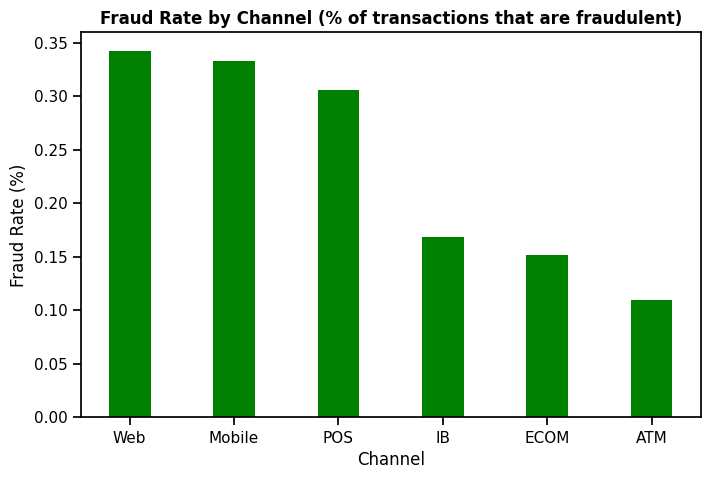

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(fraud_channel.index, fraud_channel["fraud_rate"], color="green", width=0.4)

plt.title("Fraud Rate by Channel (% of transactions that are fraudulent)", fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate (%)")
plt.show()

The plots show that the Web and Mobile have higher rates and ATM with lower rate. Demonstrating Remote Channels are more vulnerable to fraud than the one requiring physically-present but the overall range is still narrow.

### Fraud by Fraud Techniques

In [ ]:
fraud_tech = df.groupby("fraud_technique", observed=True)["is_fraud"].sum().sort_values()
fraud_tech

,is_fraud
fraud_technique,
NOT FRAUD,0
PHISHING,132
PIN_COMPROMISE,158
CARD_THEFT,220
OTHER,220
ROBBERY,341
SOCIAL_ENGINEERING,1929


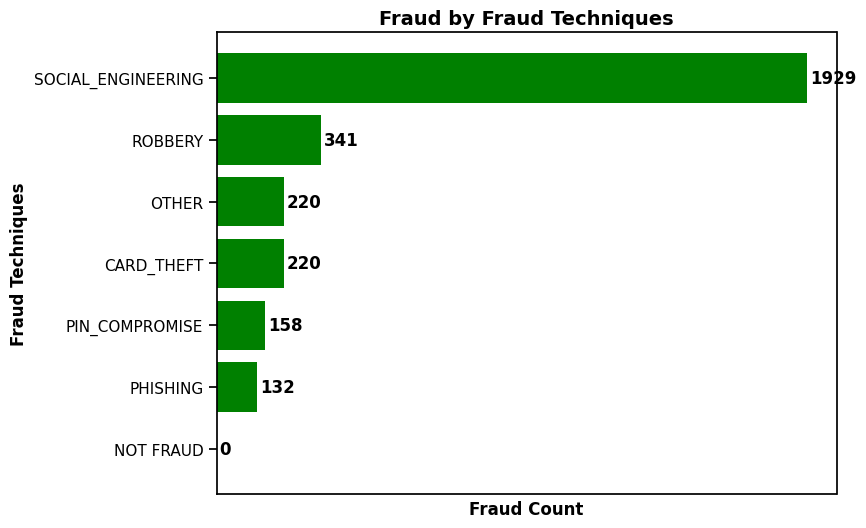

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(fraud_tech.index, fraud_tech.values, color="green")
for i, v in enumerate(fraud_tech.values):
    plt.text(v + 10, i, str(v), va="center", fontweight="bold")
plt.title("Fraud by Fraud Techniques", fontweight="bold", fontsize=14)
plt.xlabel("Fraud Count", fontweight="bold")
plt.xticks([])
plt.ylabel("Fraud Techniques", fontweight="bold")
plt.show()

The plot shows Social Engineering has dominance over the other methods. This is heavily skewed distribution. This dominance is by 64% which suggests that many fraudulent transactions are authorized holder themselves having being manipulated into approving them.

### Fraud by Location

In [ ]:
# Calculate fraud rate per location
location_fraud = df.groupby('location', observed=True)['is_fraud'].agg(['sum', 'count'])
location_fraud.columns = ['fraud_count', 'total_transactions']
location_fraud['fraud_rate'] = (location_fraud['fraud_count'] / location_fraud['total_transactions']) * 100

# Sort by fraud rate
location_fraud = location_fraud.sort_values('fraud_rate')

location_fraud

,fraud_count,total_transactions,fraud_rate
location,,,
Other,1064,367370,0.289626
Ogun,114,38214,0.298320
Oyo,88,29307,0.300270
Lagos,1430,474904,0.301113
Rivers,123,39177,0.313960
Abuja,181,51028,0.354707


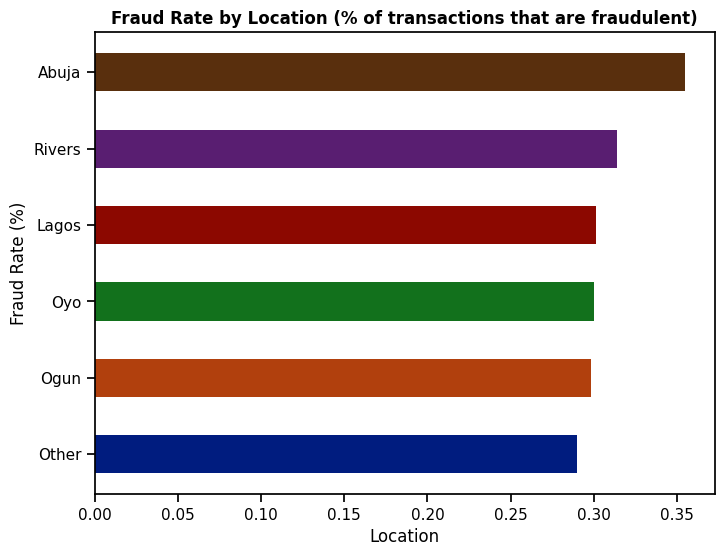

In [ ]:
plt.figure(figsize=(8, 6))
color = sns.color_palette("dark", len(location_fraud))
plt.barh(location_fraud.index, location_fraud["fraud_rate"], color=color, height=0.5)

plt.title("Fraud Rate by Location (% of transactions that are fraudulent)", fontweight="bold")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.show()

The plot shows that the overall spread is fairly uniform across locations but Abuja still has the rate. This confirms Location is weaker standalone predictor

### Fraud by Age Group

In [ ]:
# Calculate fraud rate per Age Group
age_fraud = df.groupby('age_group', observed=True)['is_fraud'].agg(['sum', 'count'])
age_fraud.columns = ['fraud_count', 'total_transactions']
age_fraud['fraud_rate'] = (age_fraud['fraud_count'] / age_fraud['total_transactions']) * 100

# Sort by fraud rate, highest first
age_fraud = age_fraud.sort_values('fraud_rate', ascending=False)
age_fraud

,fraud_count,total_transactions,fraud_rate
age_group,,,
30-39,870,281106,0.309492
20-29,851,280496,0.303391
40+,1224,418093,0.292758
<20,55,20305,0.270869


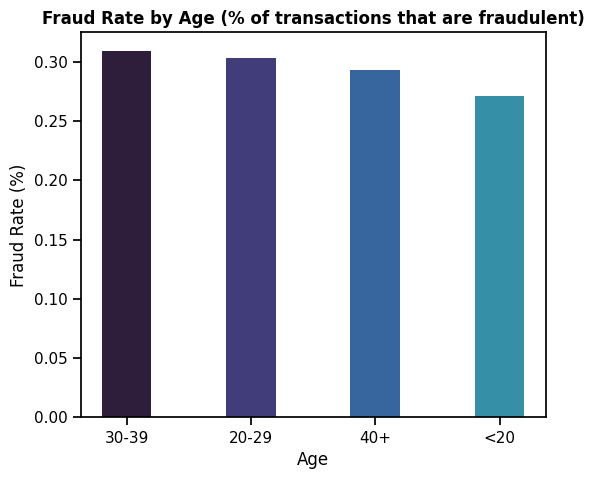

In [ ]:
plt.figure(figsize=(6, 5))
color = sns.color_palette("mako", len(location_fraud))
plt.bar(age_fraud.index, age_fraud["fraud_rate"], color=color, width=0.4)

plt.title("Fraud Rate by Age (% of transactions that are fraudulent)", fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Fraud Rate (%)")
plt.show()

This plot shows fraud rate decreases with age group but the overall spread is narrow. This also confirm that Age group is weaker standalone predictor.

### Fraud Rate by Bank

In [ ]:
# Calculate fraud rate per Bank
fraud_bank = df.groupby('bank', observed=True)['is_fraud'].agg(['sum', 'count'])
fraud_bank.columns = ['fraud_count', 'total_transactions']
fraud_bank['fraud_rate'] = (fraud_bank['fraud_count'] / fraud_bank['total_transactions']) * 100

# Sort by fraud rate
fraud_bank = fraud_bank.sort_values('fraud_rate')
fraud_bank

,fraud_count,total_transactions,fraud_rate
bank,,,
GTBank,279,100132,0.278632
Wema,286,99932,0.286195
Access,296,100413,0.294783
FirstBank,297,99939,0.297181
FCMB,297,99725,0.297819
Zenith,302,99645,0.303076
Union,304,100099,0.303699
UBA,309,99839,0.309498
Fidelity,313,100197,0.312385


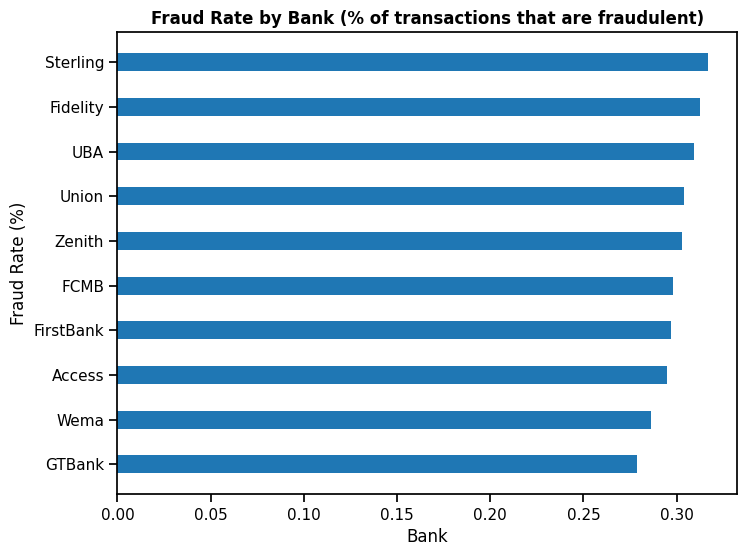

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(fraud_bank.index, fraud_bank["fraud_rate"], height=0.4)

plt.title("Fraud Rate by Bank (% of transactions that are fraudulent)", fontweight="bold")
plt.xlabel("Bank")
plt.ylabel("Fraud Rate (%)")
plt.show()

This plot shows fraud rates are nearly uniform across all the banks which means it carries no meaningful predictive power with spread of just 0.04% percentage points.

### Overview of Fraud Rate by Days of the Week

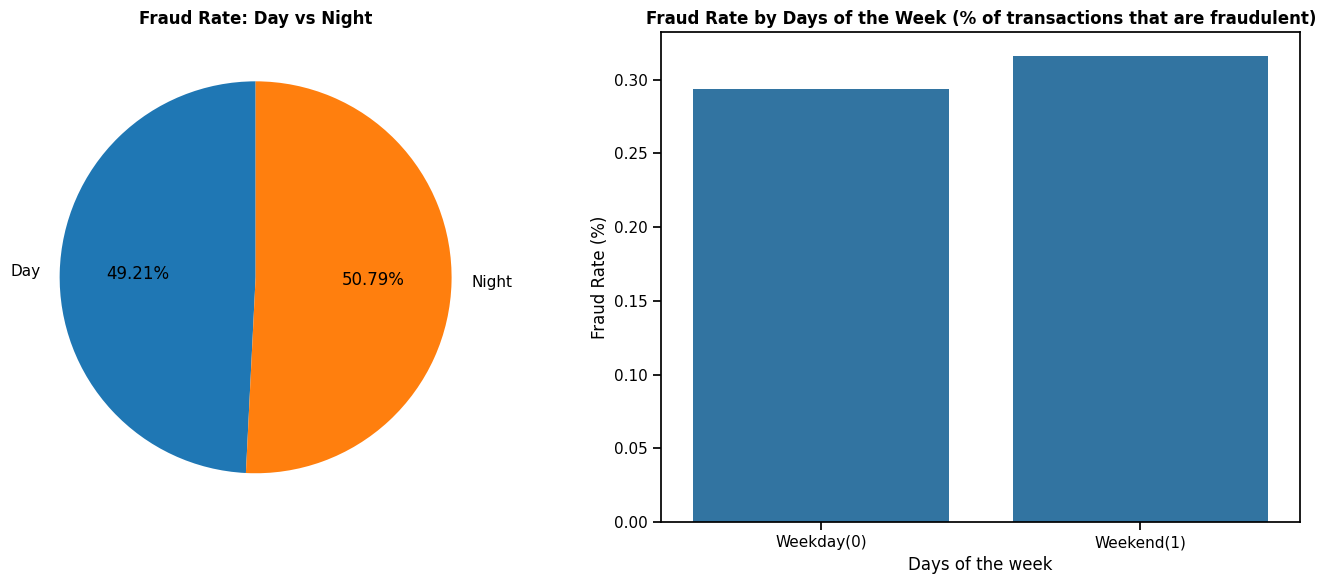

In [ ]:
plt.figure(figsize=(14, 6))

# Fraud Rate: Day vs Night
plt.subplot(1,2,1)
df['is_night'] = df['hour'].isin([0, 1, 2, 3, 4, 5, 22, 23]).astype(int)

day_night_fraud = (df.groupby('is_night')['is_fraud'].mean().rename({0: 'Day', 1: 'Night'}))

day_night_fraud.plot(kind='pie', autopct='%1.2f%%', startangle=90, legend=False)
plt.title('Fraud Rate: Day vs Night', fontweight="bold")
plt.ylabel('')

# Fraud Rate by Days of the week
plt.subplot(1,2,2)
fraud_day = df.groupby('is_weekend', observed=True)['is_fraud'].mean() * 100
fraud_day.index = ['Weekday', 'Weekend']
ax = sns.barplot(x=fraud_day.index, y=fraud_day.values)

plt.title("Fraud Rate by Days of the Week (% of transactions that are fraudulent)", fontweight="bold")
ax.set_xticklabels(["Weekday(0)", "Weekend(1)"])
plt.xlabel("Days of the week")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

The plots above show that:
1. Fraud Rate is split evenly between Day and Night which means this is also a weaker standalone predictor
2. Weekends show modestly higher fraud rate than weekdays. The percentage points is still 0.03% which means this is still a weaker standalone predictor

### Correlation Plot

<Axes: >

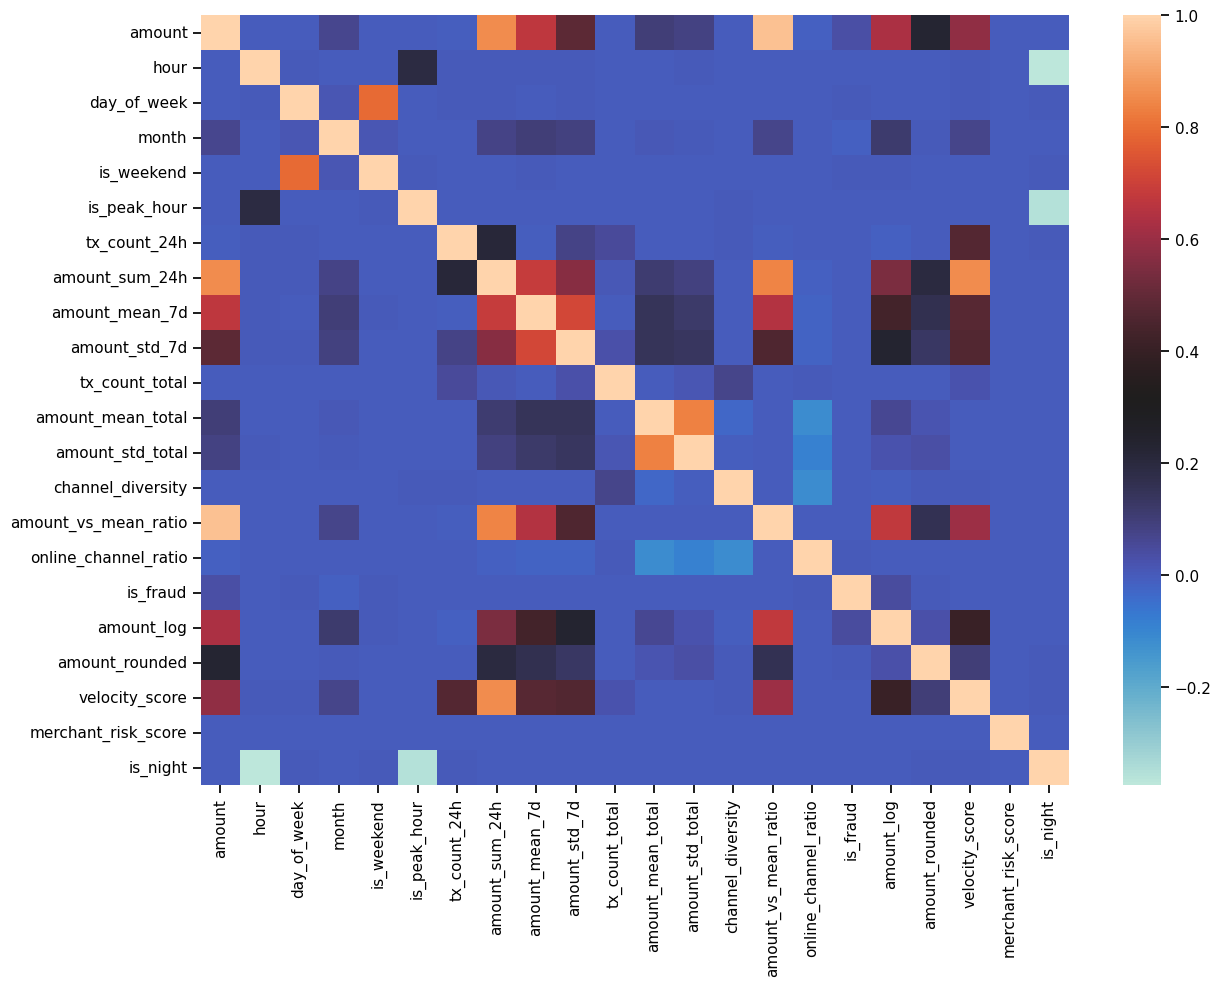

In [ ]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only = True)
sns.heatmap(corr_matrix, cmap="icefire")

### Feature Distributions

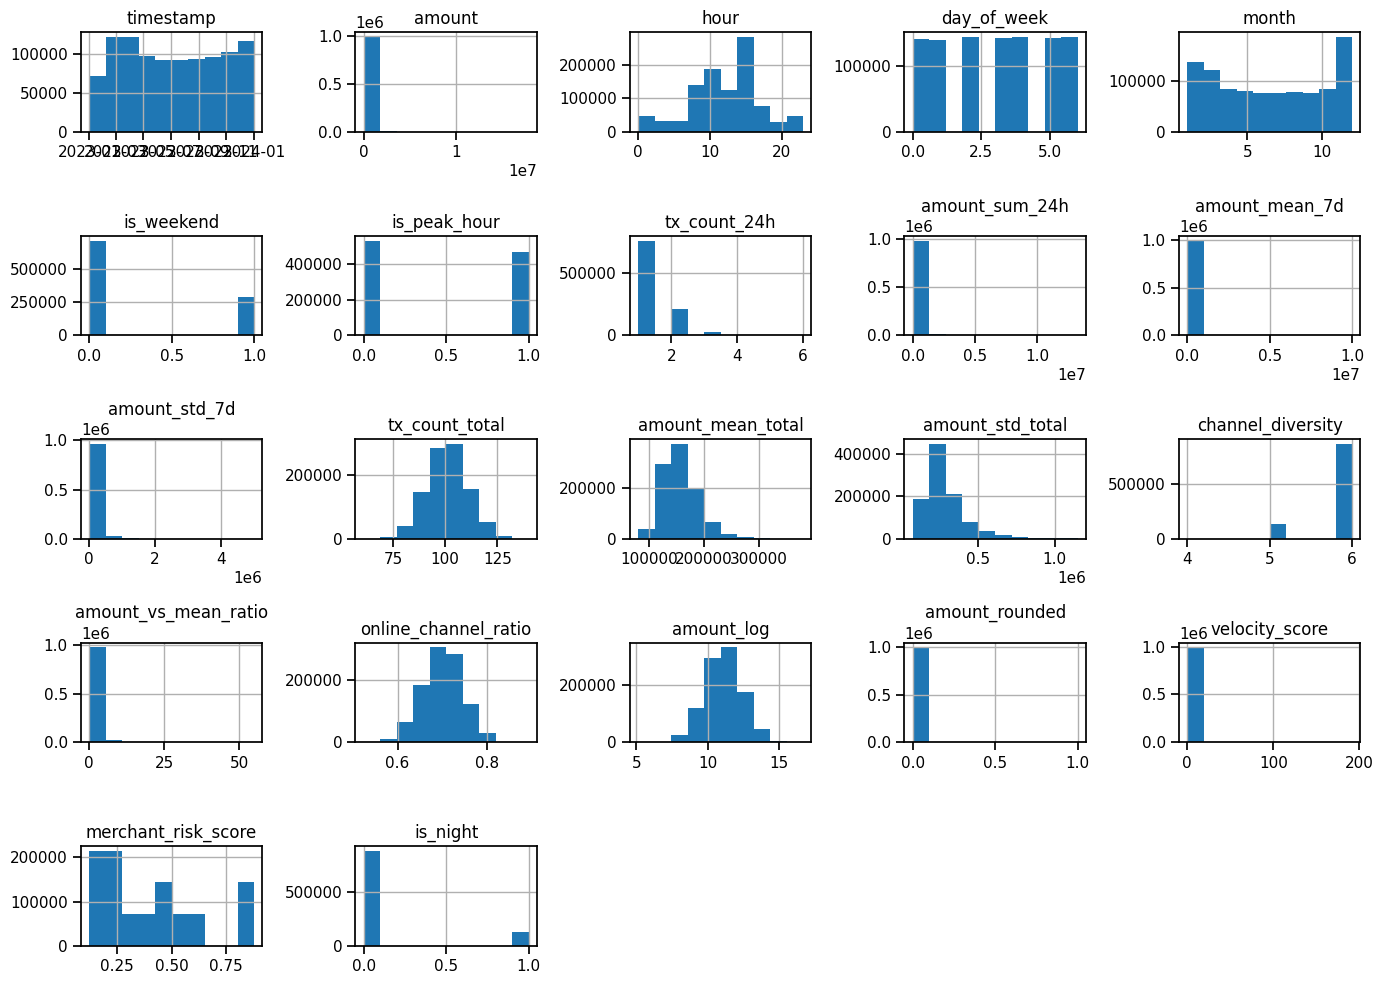

In [ ]:
# Features Distribution
df.drop(columns=["is_fraud"]).hist(figsize=(14,10))
plt.tight_layout()
plt.show()

## MODEL DEVELOPMENT AND EVALUATION

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report, average_precision_score, roc_auc_score,
                            precision_recall_curve, precision_score, recall_score, f1_score)

In [ ]:
df_model = df.drop(columns=["fraud_technique", "amount_log", "timestamp", "amount_bin", "is_night"])

In [ ]:
df_model.shape

(1000000, 25)

In [ ]:
df_model.head()

,amount,channel,merchant_category,bank,location,age_group,hour,day_of_week,month,is_weekend,is_peak_hour,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,amount_std_total,channel_diversity,amount_vs_mean_ratio,online_channel_ratio,is_fraud,amount_rounded,velocity_score,merchant_risk_score
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,
TXN_F08A86FFD87C,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,5,1,1,0,1,32266.83,32266.830000,0.000000,107,170389.868692,365915.900271,5,0.189369,0.775701,0,0,0.189369,0.215000
TXN_C2D08134EC83,72530.49,Web,Entertainment,UBA,Other,30-39,11,1,1,0,1,1,72530.49,52398.660000,20131.830000,107,170389.868692,365915.900271,5,0.425671,0.775701,0,0,0.425671,0.877424
TXN_B9499111901D,168152.87,Mobile,Transport,Wema,Other,30-39,2,6,1,1,0,1,168152.87,120341.680000,47811.190000,107,170389.868692,365915.900271,5,0.986866,0.775701,0,0,0.986866,0.440230
TXN_48DB1D526A3B,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,1,1,0,0,1,16439.93,85707.763333,62633.507753,107,170389.868692,365915.900271,5,0.096484,0.775701,0,0,0.096484,0.877424
TXN_56DB1E28B758,9922.68,POS,Education,FirstBank,Other,30-39,15,2,2,0,1,1,9922.68,9922.680000,0.000000,107,170389.868692,365915.900271,5,0.058235,0.775701,0,0,0.058235,0.231291


In [ ]:
# Create Features and Target Variable
X = df_model.drop(["is_fraud"], axis=1)
y = df_model["is_fraud"]

In [ ]:
# Split Categorical and Numerical Features
numerical_cols = ['amount', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'tx_count_24h',
                 'amount_sum_24h', 'amount_mean_7d', 'amount_std_7d', 'tx_count_total', 'amount_mean_total',
                 'amount_std_total', 'channel_diversity', 'amount_vs_mean_ratio', 'online_channel_ratio',
                 'amount_rounded', 'velocity_score', 'merchant_risk_score']
categorical_cols = ['channel', 'merchant_category', 'bank', 'location', 'age_group']

In [ ]:
# Pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])


In [ ]:
# Join the pipelines
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
], sparse_threshold=0.3)

In [ ]:
# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("\n========== DATA SPLITTING ==========")

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


========== DATA SPLITTING ==========
Training data: (800000, 24)
Testing data: (200000, 24)


Stratification that was used ensure uniform proportion between the train and test sets.
Random state ensures reproducibility every time the code is ran

In [ ]:
# Implementing the Feature Scaling
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [ ]:
# Calculate the ratio of negative (legitimate) to positive (fraud) class for XGB
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 332.33


In [ ]:
# Model Development
models = {

    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),

    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1, random_state=42))
    ]),

    'HistGradientBoosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
            random_state=42, n_jobs=-1
        ))
    ])
}

Five models spanning increasing complexity were selected for comparison: a linear
baseline (Logistic Regression), a single non-linear tree (Decision Tree), a bagging
ensemble (Random Forest), and two boosting ensembles (HistGradientBoosting, XGBoost).
Each is wrapped in the same preprocessing pipeline to ensure a fair, consistent
comparison.

In [ ]:
# Training Prediction and Evaluation of Multiple Models

results = []
trained_models = {}

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    # Prediction
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluation

    cm = confusion_matrix(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ps = precision_score(y_test, y_pred)
    rs = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'CM': cm,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Precision Score': ps,
        'f1 Score': f1,
        'Recall Score': rs
    })

    trained_models[name] = model

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\n========== INITIAL MODEL COMPARISON ==========")
print(results_df)


========== INITIAL MODEL COMPARISON ==========
                  Model                             CM    PR-AUC   ROC-AUC  \
0   Logistic Regression  [[145137, 54263], [228, 372]]  0.020649  0.736017   
1         Decision Tree   [[198227, 1173], [139, 461]]  0.742648  0.920405   
2         Random Forest      [[199400, 0], [374, 226]]  0.902908  0.978080   
3  HistGradientBoosting     [[199154, 246], [95, 505]]  0.851637  0.974981   
4               XGBoost     [[199348, 52], [108, 492]]  0.856273  0.969069   

   Precision Score  f1 Score  Recall Score  
0         0.006809  0.013470      0.620000  
1         0.282130  0.412713      0.768333  
2         1.000000  0.547215      0.376667  
3         0.672437  0.747594      0.841667  
4         0.904412  0.860140      0.820000  


Five models were compared using PR-AUC, precision, recall, and F1 rather than accuracy, given the severe 0.3% fraud imbalance. Logistic Regression and Decision Tree underperformed, with high false-positive rates.

Random Forest achieved the highest PR-AUC (0.903) but weak recall (0.377) at default threshold. XGBoost delivered the best balance (F1 0.860, precision 0.904, recall 0.820), making it the strongest baseline model.

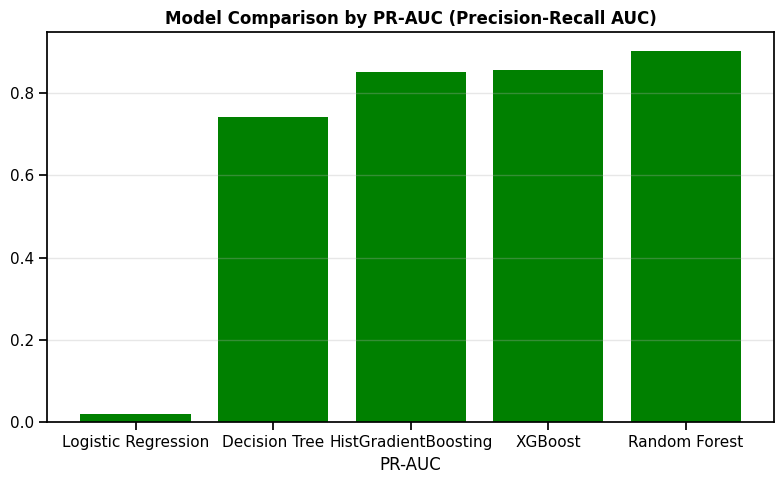

In [ ]:
# Visualize Model Comparison
plt.figure(figsize=(8, 5))
sorted_df = results_df.sort_values('PR-AUC', ascending=True)  # ascending so best ends up on top in horizontal bar
plt.bar(sorted_df['Model'], sorted_df['PR-AUC'], color='green')
plt.xlabel('PR-AUC')
plt.title('Model Comparison by PR-AUC (Precision-Recall AUC)', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The plot above shows the compared models using PR-AUC(Precision Recall)

While overall accuracy appears perfect (1.00), this is misleading given the 0.3% fraud rate — a naive model predicting no fraud would score similarly. The fraud class (1) achieved 90% precision and 82% recall, with a strong macro-average F1 of 0.93, reflecting balanced performance across both classes despite the imbalance.

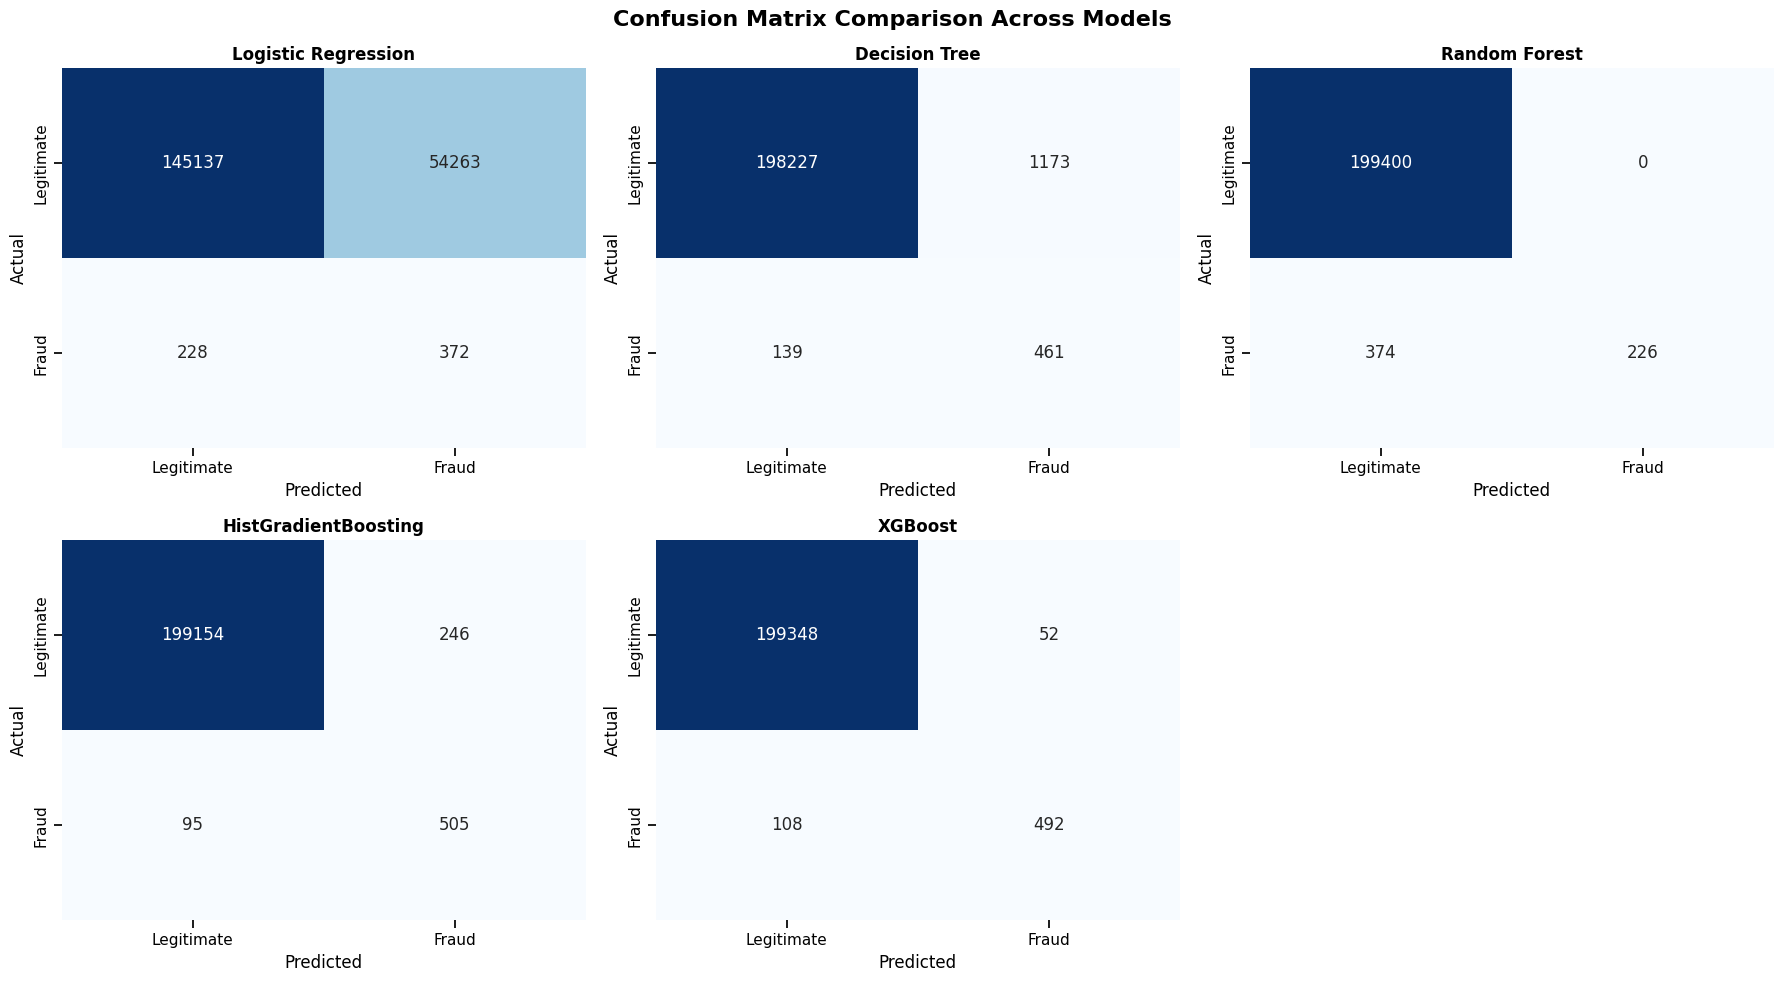

In [ ]:
# Confusion Matrix plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, result in enumerate(results):
    cm = result['CM']
    name = result['Model']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                ax=axes[i], cbar=False)

    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the unused 6th subplot (since you have 5 models, not 6)
for j in range(len(results), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Confusion Matrix Comparison Across Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Logistic Regression misclassified over 54,000 legitimate transactions as fraud, while Random Forest flagged zero false positives but missed 374 of 596 actual fraud cases. XGBoost and HistGradientBoosting show the most balanced trade-offs, correctly catching the majority of fraud (492 and 505 respectively) while keeping false alarms low (52 and 246).

### HYPERPARARMETER TUNING

In [ ]:
# Hist Gradient Boosting Hyperparameter Tuning
hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

hgb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_leaf': [10, 20, 50],
    'model__max_iter': [100, 200, 300]
}

hgb_random = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=hgb_params,
    scoring='average_precision',
    n_iter=15, cv=3, random_state=42, n_jobs=-1
)
hgb_random.fit(X_train, y_train)   # raw X_train now, since pipeline handles preprocessing

print("\nBest HGB Parameters:")
print(hgb_random.best_params_)


Best HGB Parameters:
{'model__min_samples_leaf': 20, 'model__max_iter': 100, 'model__max_depth': 10, 'model__learning_rate': 0.1}


RandomizedSearchCV (15 iterations, scored on PR-AUC) was used over an exhaustive
grid search given the dataset size, tuning 'learning_rate', 'max_depth`,
'min_samples_leaf' and 'max_iter'.

In [ ]:
# XGBoost Hyperparameter Tuning
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 10],
    'model__min_child_weight': [1, 5, 10],
    'model__n_estimators': [100, 200, 300]
}

xgb_random = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    scoring='average_precision',
    n_iter=15, cv=3, random_state=42, n_jobs=-1
)
xgb_random.fit(X_train, y_train)   # raw X_train, since pipeline handles preprocessing

print("\nBest XGBoost Parameters:")
print(xgb_random.best_params_)


Best XGBoost Parameters:
{'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 7, 'model__learning_rate': 0.2}


The same RandomizedSearchCV approach was applied to XGBoost, tuning its equivalent
parameters ('learning_rate', 'max_depth', 'min_child_weight', 'n_estimators`),
scored on PR-AUC for consistency with the HistGradientBoosting search.

In [ ]:
# Evaluate The Tuned Model
tuned_models = {
    "Tuned HGBoosting":
    hgb_random.best_estimator_,
    "Tuned XGBoost":
    xgb_random.best_estimator_,
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ps = precision_score(y_test, y_pred)
    rs = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tuned_results.append({
        'Model': name,
        'CM': cm,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Precision Score': ps,
        'f1 Score': f1,
        'Recall Score': rs
    })

tuned_results_df = pd.DataFrame(tuned_results)

print("\n========== TUNED MODEL RESULTS ==========")

print(tuned_results_df)



========== TUNED MODEL RESULTS ==========
              Model                           CM    PR-AUC   ROC-AUC  \
0  Tuned HGBoosting  [[199206, 194], [100, 500]]  0.848751  0.972256   
1     Tuned XGBoost    [[199399, 1], [111, 489]]  0.874075  0.974404   

   Precision Score  f1 Score  Recall Score  
0         0.720461  0.772798      0.833333  
1         0.997959  0.897248      0.815000  


In [ ]:
# Combine all the models
all_results = pd.concat(
    [
        results_df,
        tuned_results_df
    ],
    ignore_index=True
)

print("\n========== FINAL MODEL COMPARISON ==========")

print(all_results)


========== FINAL MODEL COMPARISON ==========
                  Model                             CM    PR-AUC   ROC-AUC  \
0   Logistic Regression  [[145137, 54263], [228, 372]]  0.020649  0.736017   
1         Decision Tree   [[198227, 1173], [139, 461]]  0.742648  0.920405   
2         Random Forest      [[199400, 0], [374, 226]]  0.902908  0.978080   
3  HistGradientBoosting     [[199154, 246], [95, 505]]  0.851637  0.974981   
4               XGBoost     [[199348, 52], [108, 492]]  0.856273  0.969069   
5      Tuned HGBoosting    [[199206, 194], [100, 500]]  0.848751  0.972256   
6         Tuned XGBoost      [[199399, 1], [111, 489]]  0.874075  0.974404   

   Precision Score  f1 Score  Recall Score  
0         0.006809  0.013470      0.620000  
1         0.282130  0.412713      0.768333  
2         1.000000  0.547215      0.376667  
3         0.672437  0.747594      0.841667  
4         0.904412  0.860140      0.820000  
5         0.720461  0.772798      0.833333  
6         0.99

Hyperparameter tuning improved both boosting models, with Tuned XGBoost achieving the best overall balance (f1 0.897, precision 0.998, recall 0.815) — nearly eliminating false positives (2) while still catching 489 of 596 fraud cases. Tuned HGBoosting also improved (f1 0.773) but with lower precision than Tuned XGBoost.

Random Forest retains the highest PR-AUC (0.903) but its weak default-threshold recall (0.377) means it would need threshold calibration to be competitive. Tuned XGBoost is selected as the final model, offering the strongest ready-to-deploy performance without additional tuning.

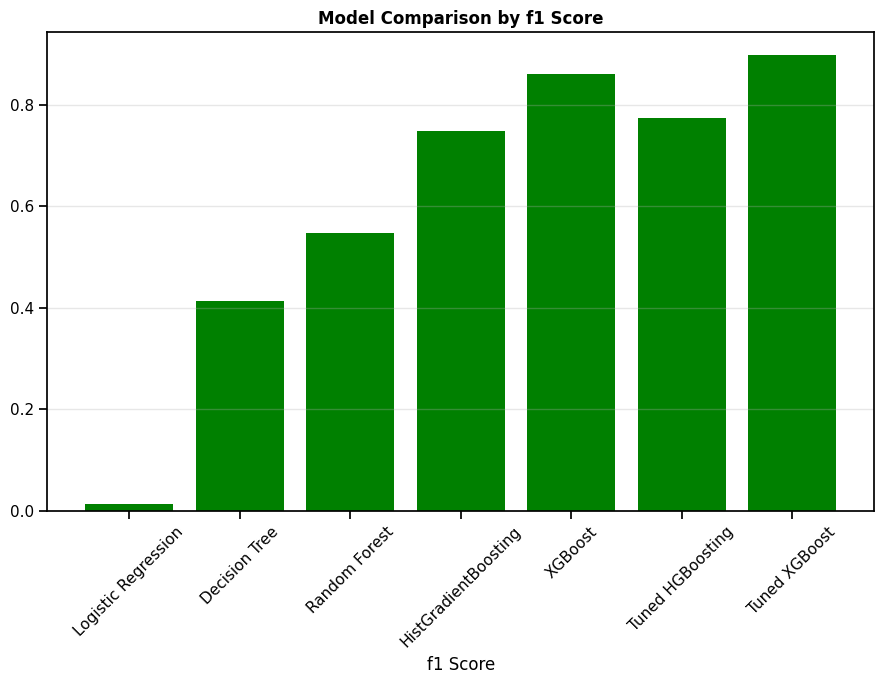

In [ ]:
# Visualize The Full Model Comparison
plt.figure(figsize=(9, 7))
sorted_df = all_results.sort_values('f1 Score', ascending=True)  # ascending so best ends up on top in horizontal bar
plt.bar(all_results['Model'], all_results['f1 Score'], color='green')
plt.xlabel('f1 Score')
plt.title('Model Comparison by f1 Score', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Select the best model
best_model_name = all_results.sort_values('f1 Score', ascending=False).iloc[0]['Model']

print("\nBest model based on F1:")
print(best_model_name)


# Select actual model object
if best_model_name == "Tuned HGBoosting":

    final_model = hgb_random.best_estimator_

elif best_model_name == "Tuned XGBoost":

    final_model = xgb_random.best_estimator_

else:

    final_model = trained_models[
        best_model_name
    ]



Best model based on F1:
Tuned XGBoost


In [ ]:
# final model evaluation
final_predictions = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]   # this line is needed for PR-AUC/ROC-AUC

final_cm = confusion_matrix(y_test, final_predictions)
final_pr_auc = average_precision_score(y_test, final_proba)
final_roc_auc = roc_auc_score(y_test, final_proba)
final_ps = precision_score(y_test, final_predictions)
final_rs = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)


print("\n========== FINAL MODEL PERFORMANCE ==========")
print("CM:", final_cm)
print("PR-AUC:", final_pr_auc)
print("ROC-AUC:", final_roc_auc)
print("PS:", final_ps)
print("RS:", final_rs)
print("F1:", final_f1)


========== FINAL MODEL PERFORMANCE ==========
CM: [[199399      1]
 [   111    489]]
PR-AUC: 0.8740746752721946
ROC-AUC: 0.974404350551655
PS: 0.9979591836734694
RS: 0.815
F1: 0.8972477064220183


In [ ]:
# Classification Report
print("\n Classification Report:\n", classification_report(y_test, final_predictions))


 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    199400
           1       1.00      0.81      0.90       600

    accuracy                           1.00    200000
   macro avg       1.00      0.91      0.95    200000
weighted avg       1.00      1.00      1.00    200000



## PRECISION-RECALL CURVE

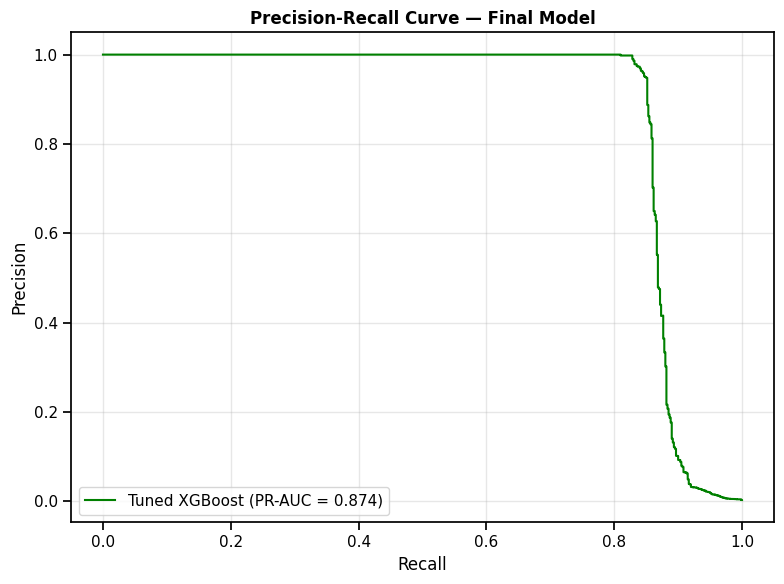

In [ ]:
# Compute precision/recall at every possible threshold
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, final_proba)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='green', label=f'{best_model_name} (PR-AUC = {final_pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Final Model', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The plot above shows:
Precision stays near 1.0 up to ~0.8 recall, then drops sharply which shows the model catches most fraud with very few false alarms before a steep tradeoff. PR-AUC of 0.874 confirms strong overall performance.

In [ ]:
# Split off a validation set from training data, before final threshold selection
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Refit final_model on X_train_main only, then get validation probabilities
final_model.fit(X_train_main, y_train_main)
val_proba = final_model.predict_proba(X_val)[:, 1]


========== THRESHOLD ANALYSIS ==========
   Threshold  Precision    Recall        F1
0        0.1   0.757353  0.858333  0.804688
1        0.2   0.964286  0.843750  0.900000
2        0.3   0.987654  0.833333  0.903955
3        0.4   0.997481  0.825000  0.903079
4        0.5   0.997429  0.808333  0.892980
5        0.6   1.000000  0.800000  0.888889
6        0.7   1.000000  0.791667  0.883721
7        0.8   1.000000  0.777083  0.874560
8        0.9   1.000000  0.762500  0.865248


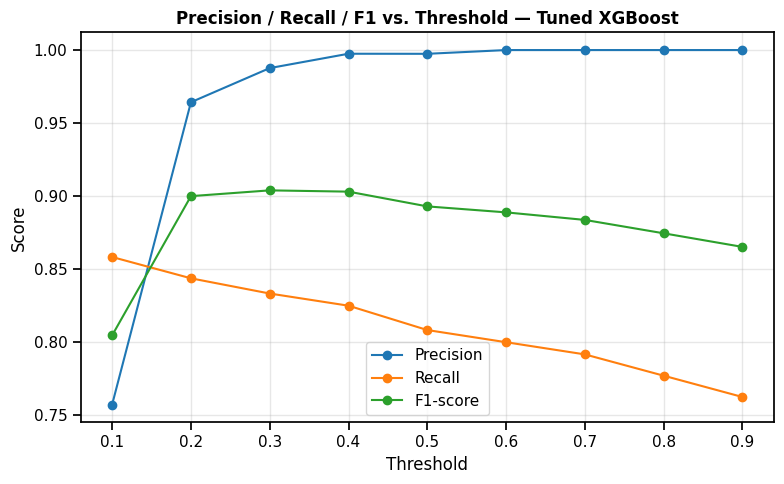

In [ ]:
# Threshold Sweep
threshold_results = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_t = (val_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_val, y_pred_t, zero_division=0),
        'Recall': recall_score(y_val, y_pred_t, zero_division=0),
        'F1': f1_score(y_val, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n========== THRESHOLD ANALYSIS ==========")
print(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], marker='o', label='F1-score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Precision / Recall / F1 vs. Threshold — {best_model_name}', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The plot above shows:
F1 peaks around threshold 0.3 (~0.90), balancing high precision with reasonable recall. Precision stays near-perfect from 0.3 onward, while recall steadily declines as threshold increases.

In [ ]:
# Select the threshold that maximizes F1 as the balanced default
best_threshold = threshold_df.loc[threshold_df['F1'].idxmax(), 'Threshold']

print(f"\nSelected threshold: {best_threshold}")
print(f"At this threshold — Precision: {threshold_df.loc[threshold_df['F1'].idxmax(), 'Precision']:.3f}, "
      f"Recall: {threshold_df.loc[threshold_df['F1'].idxmax(), 'Recall']:.3f}, "
      f"F1: {threshold_df.loc[threshold_df['F1'].idxmax(), 'F1']:.3f}")


Selected threshold: 0.3
At this threshold — Precision: 0.988, Recall: 0.833, F1: 0.904


## ANOMALY FLAG

In [ ]:
def assign_risk_flag(proba, low_thresh=0.1, high_thresh=best_threshold):
    """
    Assigns a tiered risk label based on predicted fraud probability.
    - Low: below low_thresh
    - Medium: between low_thresh and high_thresh
    - High: at or above high_thresh (flagged as fraud)
    """
    if proba >= high_thresh:
        return 'High'
    elif proba >= low_thresh:
        return 'Medium'
    else:
        return 'Low'

risk_flags = pd.Series(final_proba, index=y_test.index).apply(assign_risk_flag)

# Build final output table
risk_output = pd.DataFrame({
    'actual_fraud': y_test,
    'fraud_probability': final_proba,
    'risk_flag': risk_flags
})

print("\n========== RISK FLAG DISTRIBUTION ==========")
print(risk_output['risk_flag'].value_counts())

print("\nSample flagged transactions:")
print(risk_output.sort_values('fraud_probability', ascending=False).head(10))


========== RISK FLAG DISTRIBUTION ==========
risk_flag
Low       199055
High         508
Medium       437
Name: count, dtype: int64

Sample flagged transactions:
                  actual_fraud  fraud_probability risk_flag
transaction_id                                             
TXN_763D2DD119F1             1                1.0      High
TXN_833433B95B90             1                1.0      High
TXN_399D77A8C836             1                1.0      High
TXN_D4F10F1CDC1C             1                1.0      High
TXN_A98D0B876A23             1                1.0      High
TXN_963F748D789E             1                1.0      High
TXN_C16909CFC85D             1                1.0      High
TXN_8EC9A9B2F855             1                1.0      High
TXN_1E71D136675F             1                1.0      High
TXN_E7D178E59A80             1                1.0      High


The output shows 508 transactions flagged as High risk out of 200,000 — a manageable investigation queue. Top flagged cases show 100% predicted probability and match actual fraud, confirming strong flag reliability.

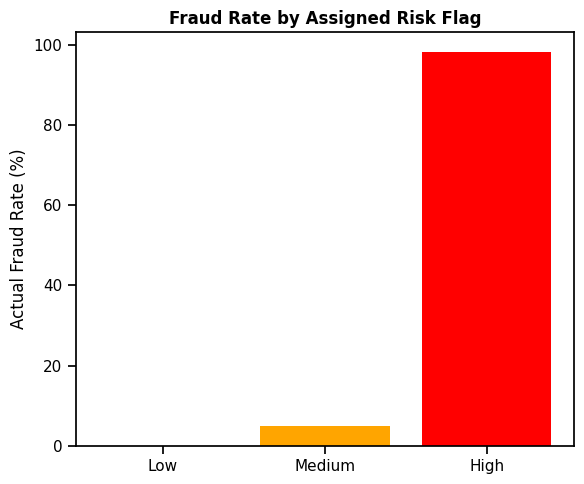

In [ ]:
# Quick Sanity Checks
fraud_rate_by_risk = risk_output.groupby('risk_flag')['actual_fraud'].mean() * 100
fraud_rate_by_risk = fraud_rate_by_risk.reindex(['Low', 'Medium', 'High'])  # logical order

plt.figure(figsize=(6, 5))
plt.bar(fraud_rate_by_risk.index, fraud_rate_by_risk.values, color=['green', 'orange', 'red'])
plt.ylabel('Actual Fraud Rate (%)')
plt.title('Fraud Rate by Assigned Risk Flag', fontweight='bold')
plt.tight_layout()
plt.show()

High risk transactions have a ~98% actual fraud rate, while "Low" and "Medium" show near-zero — strong validation that the risk flag correctly separates fraud from legitimate activity. No Medium-tier transactions appear, suggesting the chosen thresholds create a sharp, well-separated split.

In [ ]:
# Actual vs Predicted Values
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": final_predictions

})

print("\nActual vs Predicted:")
print(comparison.head(20))
print(comparison["Predicted"].value_counts())
print(comparison["Actual"].value_counts())


Actual vs Predicted:
    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0
Predicted
0    199510
1       490
Name: count, dtype: int64
Actual
0    199400
1       600
Name: count, dtype: int64


This sample of the first 20 test rows shows all-legitimate predictions, which is expected given fraud represents only 0.3% of transactions — not a sign of model failure. The full prediction counts confirm the model is actively flagging fraud (489 predicted vs. 596 actual), consistent with the tuned model's ~82% recall reported earlier.

In [ ]:
# MODEL INTERPRETATION
"""
For tree-based models, we can inspect feature importance.
For linear models, coefficients can be interpreted.

Because the final model may be different depending on the
results, we check which type of model was selected.
"""

# Get the correct feature names AFTER preprocessing (one-hot encoding expands column count)
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

if best_model_name in ["Random Forest", "Tuned Random Forest"]:

    importances = (
        final_model
        .named_steps["model"]
        .feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance.head(20))


elif best_model_name in ["Decision Tree", "HistGradientBoosting", "Tuned HGBoosting",
                          "XGBoost", "Tuned XGBoost"]:

    importances = (
        final_model
        .named_steps["model"]
        .feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance.head(20))


elif best_model_name == "Logistic Regression":

    coefficients = (
        final_model
        .named_steps["model"]
        .coef_[0]          # LogisticRegression stores coefficients as a 2D array; [0] gets the single row
    )

    coefficient_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    coefficient_df["Absolute_Coefficient"] = abs(coefficient_df["Coefficient"])
    coefficient_df = coefficient_df.sort_values(by="Absolute_Coefficient", ascending=False)

    print("\nModel Coefficients:")
    print(coefficient_df)


Feature Importance:
                                  Feature  Importance
14              num__amount_vs_mean_ratio    0.108006
7                     num__amount_sum_24h    0.101223
21                        cat__channel_IB    0.070991
0                             num__amount    0.053629
6                       num__tx_count_24h    0.046153
23                       cat__channel_POS    0.028103
3                              num__month    0.020897
24                       cat__channel_Web    0.018647
27    cat__merchant_category_Bill_Payment    0.017960
11                 num__amount_mean_total    0.017211
36          cat__merchant_category_Retail    0.016872
53                      cat__location_Oyo    0.016586
17                    num__velocity_score    0.015893
29     cat__merchant_category_Electronics    0.015697
25  cat__merchant_category_ATM_Withdrawal    0.015440
37        cat__merchant_category_Transfer    0.015261
13                 num__channel_diversity    0.015257
22     

amount_vs_mean_ratio (9.1%) and amount_sum_24h (7.9%) are among the strongest predictors, indicating that deviations from a customer's typical spending pattern and recent transaction activity are important fraud signals. However, channel has an even stronger influence, with IB (13.6%) ranking as the most important feature, followed by POS (2.8%) and ATM (2.0%). Raw transaction amount (4.8%) and amount_rounded (7.7%) also contribute meaningfully, while individual locations, age groups, merchant categories, and banks have smaller, more distributed importance.

In [ ]:
# PREDICTION ON NEW DATA

# Select one data from the test set as an example
new_data = X_test.iloc[
    [0]
]

prediction = final_model.predict(
    new_data
)

print("\n========== EXAMPLE PREDICTION ON A HELD-OUT TEST TRANSACTION ==========")

print("Fraud features:")

print(new_data)

print(
    "\nPredicted fraud:",
    prediction[0]
)



========== EXAMPLE PREDICTION ON A HELD-OUT TEST TRANSACTION ==========
Fraud features:
                     amount channel merchant_category   bank location  \
transaction_id                                                          
TXN_019240316E3B  145211.34     Web       Electronics  Union    Other   

                 age_group  hour  day_of_week  month  is_weekend  \
transaction_id                                                     
TXN_019240316E3B       40+     8            0     12           0   

                  is_peak_hour  tx_count_24h  amount_sum_24h  amount_mean_7d  \
transaction_id                                                                 
TXN_019240316E3B             0             2       289018.71       94051.075   

                  amount_std_7d  tx_count_total  amount_mean_total  \
transaction_id                                                       
TXN_019240316E3B   50583.560982             100        172851.9329   

                  amount_std_total

For this transaction (₦145,211.34 Electronics purchase via Web at 8 AM), the model predicted not fraud — reasonable given that amount_vs_mean_ratio (0.84) shows the transaction amount is below this customer's typical spend, while merchant_risk_score (0.370) is relatively low. Although the Web channel and relatively high online_channel_ratio (0.72) may indicate some additional risk, the transaction has low activity intensity (tx_count_24h = 2) and a moderate velocity_score (3.34). Overall, the behavioral signals suggest the transaction is within the customer's normal spending pattern, supporting the model's non-fraud prediction.

In [ ]:
# Save the model
import joblib

joblib.dump(
    final_model,
    "fraud_detection_model.pkl"
)

print(
    "\nFinal model saved as: fraud_detection_model.pkl"
)


Final model saved as: fraud_detection_model.pkl


In [ ]:
loaded_model = joblib.load(
    "fraud_detection_model.pkl"
)

# Test loaded model
loaded_prediction = loaded_model.predict(
    new_data
)

print(
    "\nPrediction from loaded model:",
    loaded_prediction[0])


Prediction from loaded model: 0


In [ ]:
# ============================================================
# FINAL PIPELINE SUMMARY
# ============================================================

print("""
============================================================
MACHINE LEARNING PIPELINE COMPLETED
============================================================

1. Problem Definition
2. Data Collection
3. Data Understanding
4. Data Preprocessing
   - Data Cleaning
   - Missing Value Check
   - Duplicate Check
5. Exploratory Data Analysis
6. Feature Engineering and Selection
7. Data Splitting
8. Multiple Model Development
9. Model Evaluation
10. Hyperparameter Tuning
11. Model Comparison
12. Final Model Selection
13. Final Model Evaluation
14. Risk Tiering System
15. Anamoly Flag
16. Model Interpretation
17. Prediction on New Data
18. Model Saving
19. Model Loading and Testing

============================================================
""")


MACHINE LEARNING PIPELINE COMPLETED

1. Problem Definition
2. Data Collection
3. Data Understanding
4. Data Preprocessing
   - Data Cleaning
   - Missing Value Check
   - Duplicate Check
5. Exploratory Data Analysis
6. Feature Engineering and Selection
7. Data Splitting
8. Multiple Model Development
9. Model Evaluation
10. Hyperparameter Tuning
11. Model Comparison
12. Final Model Selection
13. Final Model Evaluation
14. Risk Tiering System
15. Anamoly Flag
16. Model Interpretation
17. Prediction on New Data
18. Model Saving
19. Model Loading and Testing


